# CycleSense

# Notebook 03: Exploratory Data Analysis

## Objective

The objective of this notebook is to understand the cleaned menstrual cycle dataset through descriptive statistics and visual exploration. We identify important feature groups, investigate relationships between variables, detect outliers, examine target distributions, and identify potential sources of data leakage before feature engineering.

---

## Research Motivation

Exploratory Data Analysis (EDA) is a critical step in biomedical machine learning. Understanding the statistical properties and relationships within menstrual cycle data enables informed feature selection and helps build interpretable predictive models.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
from src.config import PROCESSED_DATA_DIR

In [4]:
df = pd.read_csv(
    PROCESSED_DATA_DIR / "cleaned_cycle_data.csv"
)

print(df.shape)

df.head()

(1653, 80)


,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,...,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1,0,1,0,29,27.33,17.0,12.0,12.0,...,9.0,2.0,32009,2.0,7.0,7.0,1.0,1.0,0.0,21.254724
1,nfp8122,2,0,1,0,27,29.50,15.0,12.0,13.0,...,9.0,2.0,32009,3.0,3.0,3.0,1.0,1.0,0.0,24.114742
2,nfp8122,3,0,1,0,29,29.50,15.0,14.0,11.0,...,9.0,2.0,32009,3.0,3.0,3.0,1.0,1.0,0.0,24.114742
3,nfp8122,4,0,1,0,27,29.50,15.0,12.0,13.0,...,9.0,2.0,32009,3.0,3.0,3.0,1.0,1.0,0.0,24.114742
4,nfp8122,5,0,1,0,28,29.50,16.0,12.0,12.0,...,9.0,2.0,32009,3.0,3.0,3.0,1.0,1.0,0.0,24.114742


# Feature Categories

The variables in the dataset can be grouped into several clinically meaningful categories.

In [5]:
feature_groups = {

    "Identifiers":[
        "ClientID",
        "CycleNumber"
    ],

    "Cycle Features":[
        "LengthofCycle",
        "EstimatedDayofOvulation",
        "LengthofLutealPhase",
        "MeanCycleLength"
    ],

    "Menstrual Health":[
        "LengthofMenses",
        "MeanMensesLength",
        "TotalMensesScore",
        "MeanBleedingIntensity"
    ],

    "Demographics":[
        "Age",
        "BMI",
        "Height",
        "Weight"
    ],

    "Pregnancy History":[
        "Numberpreg",
        "Livingkids",
        "Miscarriages",
        "Abortions"
    ]

}

feature_groups

{'Identifiers': ['ClientID', 'CycleNumber'],
 'Cycle Features': ['LengthofCycle',
  'EstimatedDayofOvulation',
  'LengthofLutealPhase',
  'MeanCycleLength'],
 'Menstrual Health': ['LengthofMenses',
  'MeanMensesLength',
  'TotalMensesScore',
  'MeanBleedingIntensity'],
 'Demographics': ['Age', 'BMI', 'Height', 'Weight'],
 'Pregnancy History': ['Numberpreg',
  'Livingkids',
  'Miscarriages',
  'Abortions']}

In [6]:
for category, cols in feature_groups.items():

    print("="*50)

    print(category)

    print(f"{len(cols)} Features")

    print(cols)

Identifiers
2 Features
['ClientID', 'CycleNumber']
Cycle Features
4 Features
['LengthofCycle', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'MeanCycleLength']
Menstrual Health
4 Features
['LengthofMenses', 'MeanMensesLength', 'TotalMensesScore', 'MeanBleedingIntensity']
Demographics
4 Features
['Age', 'BMI', 'Height', 'Weight']
Pregnancy History
4 Features
['Numberpreg', 'Livingkids', 'Miscarriages', 'Abortions']


# Dataset Statistics

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CycleNumber,1653.0,8.072595,6.604134,1.000000,3.000000,7.000000,11.000000,45.00000
Group,1653.0,0.385360,0.486828,0.000000,0.000000,0.000000,1.000000,1.00000
CycleWithPeakorNot,1653.0,0.913491,0.281200,0.000000,1.000000,1.000000,1.000000,1.00000
ReproductiveCategory,1653.0,0.055656,0.481422,0.000000,0.000000,0.000000,0.000000,9.00000
LengthofCycle,1653.0,29.320629,3.889520,18.000000,27.000000,29.000000,31.000000,54.00000
...,...,...,...,...,...,...,...,...
NextpregM,1653.0,2.995160,0.707090,0.000000,3.000000,3.000000,3.000000,7.00000
Spousesame,1653.0,0.999395,0.042610,0.000000,1.000000,1.000000,1.000000,2.00000
SpousesameM,1653.0,0.998185,0.042576,0.000000,1.000000,1.000000,1.000000,1.00000
Timeattemptpreg,1653.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


# Correlation Analysis

In [8]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

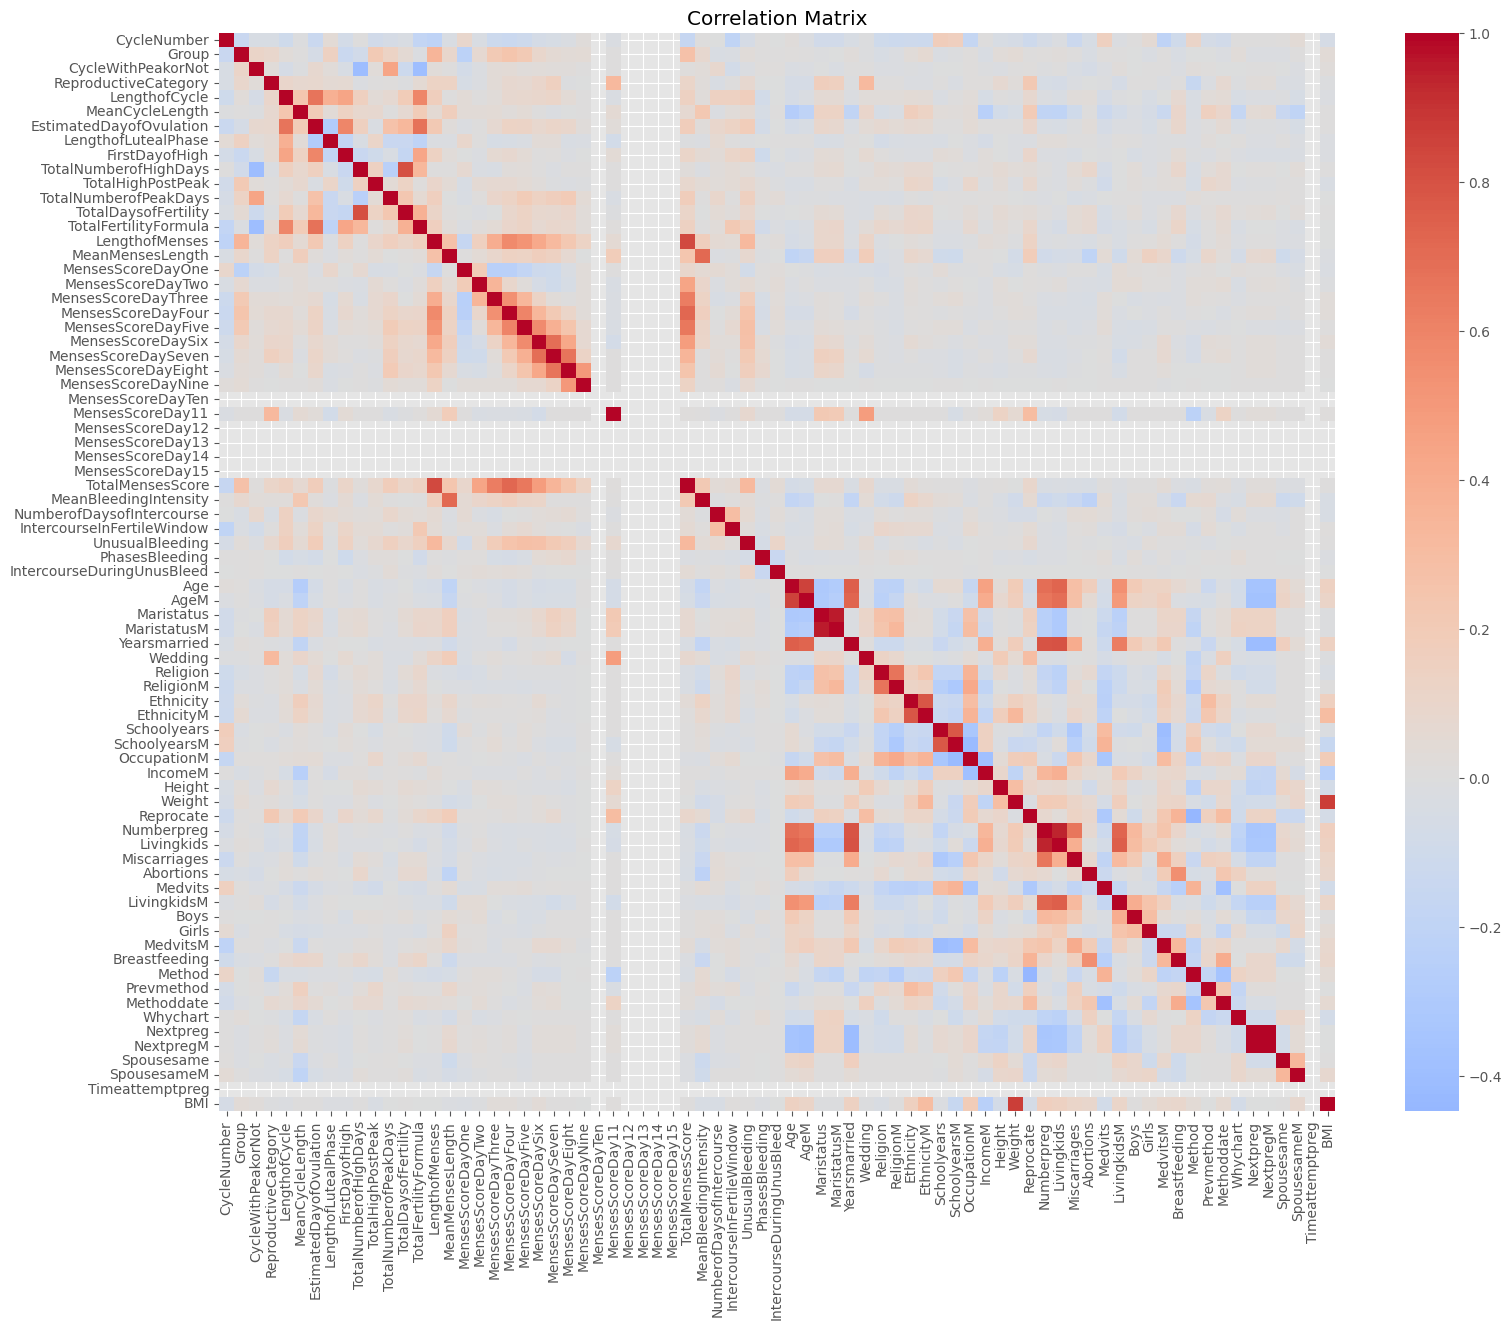

In [9]:
plt.figure(figsize=(18,14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

# Target Variable Distributions

In [10]:
targets = [
    "EstimatedDayofOvulation",
    "LengthofCycle",
    "CycleWithPeakorNot"
]

df[targets].describe()

,EstimatedDayofOvulation,LengthofCycle,CycleWithPeakorNot
count,1653.000000,1653.000000,1653.000000
mean,15.880218,29.320629,0.913491
std,3.402061,3.889520,0.281200
min,6.000000,18.000000,0.000000
25%,14.000000,27.000000,1.000000
50%,15.000000,29.000000,1.000000
75%,18.000000,31.000000,1.000000
max,29.000000,54.000000,1.000000


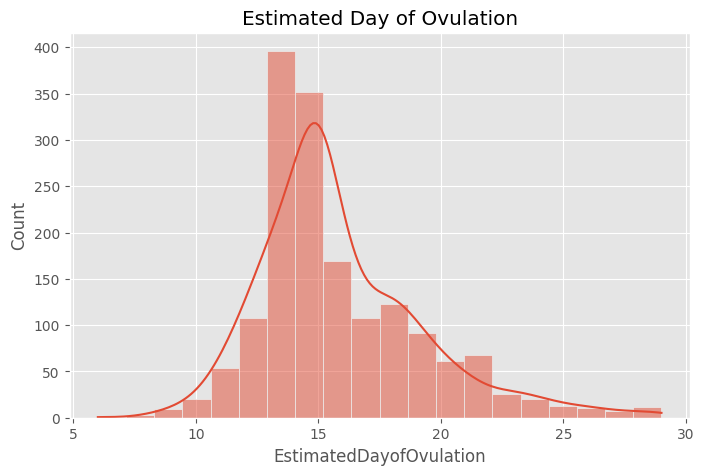

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["EstimatedDayofOvulation"],
    bins=20,
    kde=True
)

plt.title("Estimated Day of Ovulation")

plt.show()

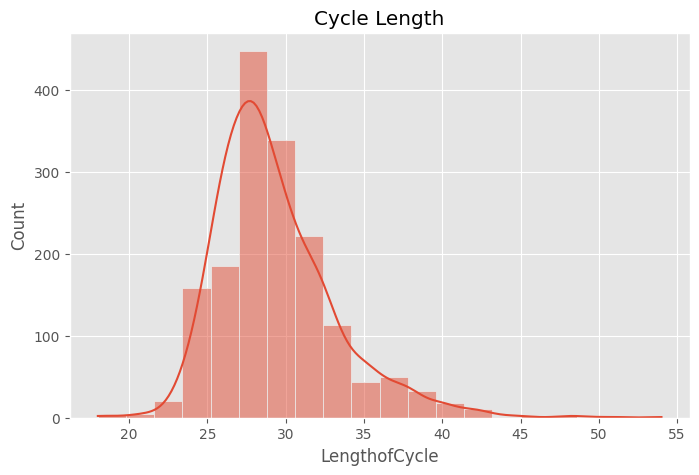

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["LengthofCycle"],
    bins=20,
    kde=True
)

plt.title("Cycle Length")

plt.show()

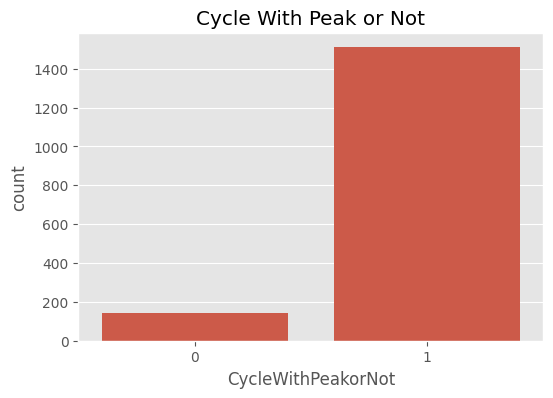

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="CycleWithPeakorNot",
    data=df
)

plt.title("Cycle With Peak or Not")

plt.show()

# Important Biomedical Features

In [14]:
important_features = [
    "Age",
    "BMI",
    "LengthofCycle",
    "EstimatedDayofOvulation",
    "LengthofLutealPhase"
]

df[important_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1653.0,30.967937,1.644438,21.000000,31.000000,31.000000,31.000000,43.00000
BMI,1653.0,24.193598,1.572212,16.826657,24.114742,24.114742,24.114742,49.91716
LengthofCycle,1653.0,29.320629,3.889520,18.000000,27.000000,29.000000,31.000000,54.00000
EstimatedDayofOvulation,1653.0,15.880218,3.402061,6.000000,14.000000,15.000000,18.000000,29.00000
LengthofLutealPhase,1653.0,13.261343,2.545363,1.000000,12.000000,13.000000,14.000000,41.00000


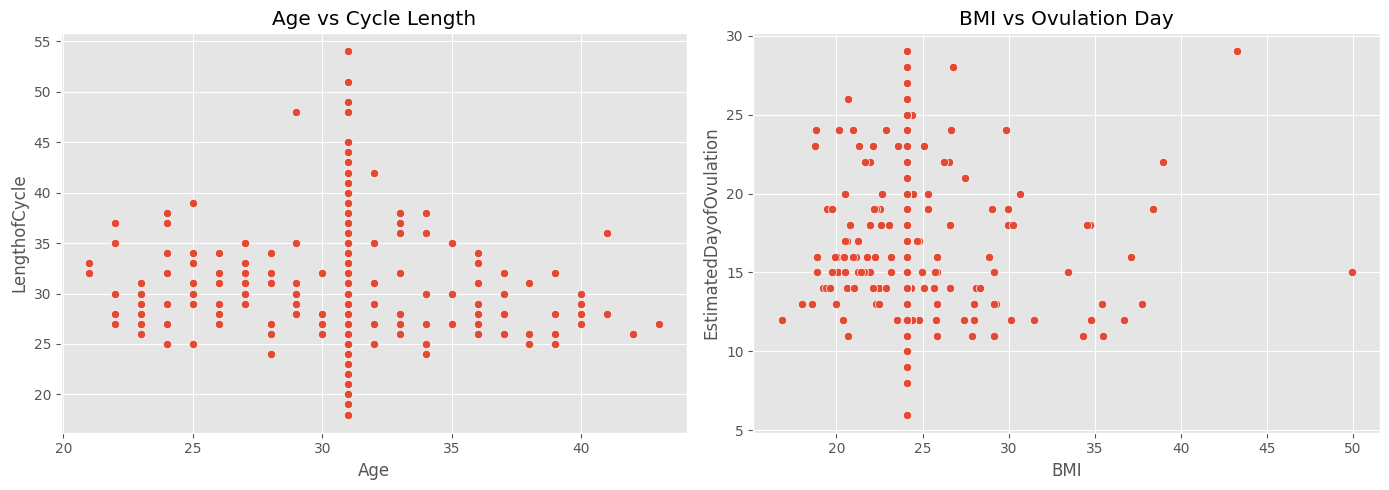

In [15]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="LengthofCycle",
    ax=ax[0]
)

ax[0].set_title("Age vs Cycle Length")

sns.scatterplot(
    data=df,
    x="BMI",
    y="EstimatedDayofOvulation",
    ax=ax[1]
)

ax[1].set_title("BMI vs Ovulation Day")

plt.tight_layout()

plt.show()

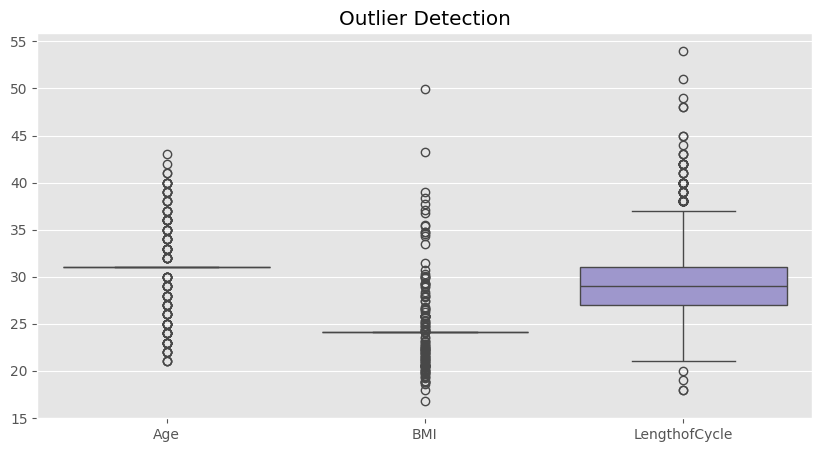

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df[
        ["Age","BMI","LengthofCycle"]
    ]
)

plt.title("Outlier Detection")

plt.show()

# Potential Data Leakage

Some variables are calculated after the menstrual cycle is complete (e.g., Total Day of Fertility, Length of Luteal Phase). These variables may leak future information if used as predictors.

A detailed feature selection strategy will therefore be applied before model development.

In [18]:
possible_leakage = [

    "EstimatedDayofOvulation",

    "LengthofCycle",

    "LengthofLutealPhase",

    "FirstDayofHigh",

    "TotalNumberofHighDays",

    "TotalHighPostPeak",

    "TotalNumberofPeakDays",

    "TotalDaysofFertility",

    "TotalFertilityFormula"

]

pd.DataFrame({
    "Potential Leakage Features": possible_leakage
})

,Potential Leakage Features
0,EstimatedDayofOvulation
1,LengthofCycle
2,LengthofLutealPhase
3,FirstDayofHigh
4,TotalNumberofHighDays
5,TotalHighPostPeak
6,TotalNumberofPeakDays
7,TotalDaysofFertility
8,TotalFertilityFormula


# Conclusions

Key observations from the exploratory analysis:

- The dataset contains demographic, physiological, reproductive, and behavioral variables.
- Target variables show reasonable distributions for machine learning.
- Several biomedical variables exhibit strong correlations.
- Potential data leakage variables have been identified and will be excluded where appropriate.
- Feature engineering will be performed in the next notebook to prepare optimized datasets for regression and classification models.